Preprocesamiento

In [298]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
x, y = iris.data, iris.target

mask = y < 2
x_filtered = x[mask]
y_filtered = y[mask]
y_reshaped = y_filtered.reshape(-1,1)

Division de Datos

In [299]:
x_train, x_test, y_train, y_test = train_test_split(
    x_filtered, y_reshaped, test_size=0.3, random_state=42
)

Normalizacion de Datos

In [300]:
#normalizamos los datos
#el scaler debe de aprender solamente de los datos de entrenamiento
#calcula la media (mu) y la desviacion estandar (sigma)
#de cada caracteristica del conjunto de entrenamiento

scaler = StandardScaler()

#reemplazamos los valores de x_train con las muestras escaladas
x_train = scaler.fit_transform(x_train)

#los valores de x_test se transforman usando los parametros
#aprendidos del conjunto de entrenamiento, mu y sigma
#la funcion de transform no vuelve a calcular mu ni sigma
x_test = scaler.transform(x_test)

Implementacion de clases con los algoritmos de Momentum y Adam

In [301]:
class NeuralNetwork:
    def __init__(self, input_dim, algorithm):
        np.random.seed(42)
        #pesos iniciales aleatorios
        self.weights = np.random.randn(input_dim, 1)
        #sesgo inicial en ceros
        self.bias = np.zeros((1,1))
        #guarda el tipo de algoritmo ('momentum' o 'adam')
        self.algorithm = algorithm.lower()

        #variables de memoria de momentum
        self.v_w = np.zeros_like(self.weights)
        self.v_b = np.zeros_like(self.bias)

        #variables de memoria para adam (necesitas momentos m y v, segun la ecuacion)
        self.m_w = np.zeros_like(self.weights)
        self.v_w_adam = np.zeros_like(self.weights)
        self.m_b = np.zeros_like(self.bias)
        self.v_b_adam = np.zeros_like(self.bias)
        #contador de actualizaciones para adam
        self.t = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    #se entrena por 1,000 epocas
    def train(self, x_train, y_reshaped, epochs=1000, learning_rate=0.1):
        loss_history = []

        for epoch in range(epochs):

            #gradiente descendiente estocastico con momentum
            if self.algorithm == 'momentum':

                #se mezclan las muestras en cada epoca
                indices = np.random.permutation(len(x_train))

                #se procesa una muestra a la vez
                for i in indices:
                    #seleccionamos una sola muestra
                    x_i = x_train[i:i+1]
                    y_i = y_reshaped[i:i+1]

                    #forward pass
                    #multiplica las entradas por los pesos actuales y le suma el sesgo
                    #despues pasa el resultado por la sigmoide para predecir a cual clase
                    #pertenece de flor
                    linear_output = np.dot(x_i, self.weights) + self.bias
                    prediction = self.sigmoid(linear_output)

                    #gradiente - backward pass
                    #dL/dz = prediction - y
                    error = prediction - y_i

                    #como solamente estamos procesando una muestra individual,
                    #no es necesario dividir entre len(x_train)
                    grad_w = np.dot(x_i.T, error)
                    grad_b = np.sum(error)

                    #el algoritmo
                    beta = 0.9

                    self.v_w = beta * self.v_w + (1-beta) * grad_w
                    self.v_b = beta * self.v_b + (1-beta) * grad_b

                    self.weights -= learning_rate * self.v_w
                    self.bias -= learning_rate * self.v_b

                #al terminar la epoca se calcula el loss usando todo el conjunto
                #de entrenamiento
                linear_output = np.dot(x_train, self.weights) + self.bias
                predictions = self.sigmoid(linear_output)

                epsilon = 1e-15
                preds_clipped = np.clip(predictions, epsilon, 1-epsilon)

                loss = -np.mean(
                    y_reshaped * np.log(preds_clipped) +
                    (1 - y_reshaped) * np.log(1 - preds_clipped)
                )

                loss_history.append(loss)

            #adam (adaptive moment estimation)
            elif self.algorithm == 'adam':
                #forward pass
                #multiplica las entradas por los pesos actuales y le suma el sesgo
                #despues pasa el resultado por la sigmoide para predecir a cual clase
                #pertenece de flor
                linear_output = np.dot(x_train, self.weights) + self.bias
                predictions = self.sigmoid(linear_output)

                #mide el error usando entropia cruzada binaria y guarda el resultado
                #para poder graficarlo despues
                epsilon = 1e-15
                #el clip es para evitar el ln(0) que es un valor indefinido
                preds_clipped = np.clip(predictions, epsilon, 1-epsilon)

                loss = -np.mean(
                    y_reshaped * np.log(preds_clipped) +
                     (1 - y_reshaped) * np.log(1 - preds_clipped)
                )

                loss_history.append(loss)

                #gradiente - backward pass
                #aplica calculo diferencial (la regla de la cadena)
                #para saber exactamente en que direccion y con que magnitud deben
                #modificarse los pesos para cometer menos errores
                #para sigmoide + binary cross entropy, la derivada se simplifica a:
                #dL/dz = predictions - y
                error = predictions - y_reshaped

                grad_w = np.dot(x_train.T, error) / len(x_train)
                grad_b = np.sum(error) / len(x_train)

                #el algoritmo
                beta1, beta2, eps = 0.9, 0.999, 1e-8
                self.t += 1

                self.m_w = beta1 * self.m_w + (1 - beta1) * grad_w
                self.v_w_adam = beta2 * self.v_w_adam + (1 - beta2) * (grad_w ** 2)

                m_w_hat = self.m_w / (1 - (beta1 ** self.t))
                v_w_hat = self.v_w_adam / (1 - (beta2 ** self.t))

                self.m_b = beta1 * self.m_b + (1 - beta1) * grad_b
                self.v_b_adam = beta2 * self.v_b_adam + (1 -  beta2) * (grad_b ** 2)

                m_b_hat = self.m_b / (1 - (beta1 ** self.t))
                v_b_hat = self.v_b_adam / (1 - (beta2 ** self.t))

                self.weights -= learning_rate * m_w_hat / (np.sqrt(v_w_hat) + eps)
                self.bias -= learning_rate * m_b_hat / (np.sqrt(v_b_hat) + eps)

        return loss_history

    def predict(self, x):
        #se calcula z (la combinacion lineal)
        #ya despues de calcular los pesos y bias con el entrenamiento
        linear_output = np.dot(x, self.weights) + self.bias

        #se pasa el resultado de linear_output a la funcion sigmoide
        resultado_sigmoide = self.sigmoid(linear_output)

        #se evalua si el resultado de la sigmoide es mayor o menor a 0.5 (el umbral)
        #y se evalua a 0 o 1
        return (resultado_sigmoide >= 0.5).astype(int)

Entrenamiento

In [302]:
neuron_momentum = NeuralNetwork(input_dim=4, algorithm='momentum')
loss_momentum = neuron_momentum.train(x_train, y_train, epochs=1000, learning_rate=0.1)

neuron_adam = NeuralNetwork(input_dim=4, algorithm='adam')
loss_adam = neuron_adam.train(x_train, y_train, epochs=1000, learning_rate=0.1)

y_pred_momentum = neuron_momentum.predict(x_test)
y_pred_adam = neuron_adam.predict(x_test)

Evaluacion

In [303]:
acc_momentum = accuracy_score(y_test, y_pred_momentum)
acc_adam = accuracy_score(y_test, y_pred_adam)

print("Accuracy Momentum:", acc_momentum)
print("Accuracy Adam:", acc_adam)

Accuracy Momentum: 1.0
Accuracy Adam: 1.0


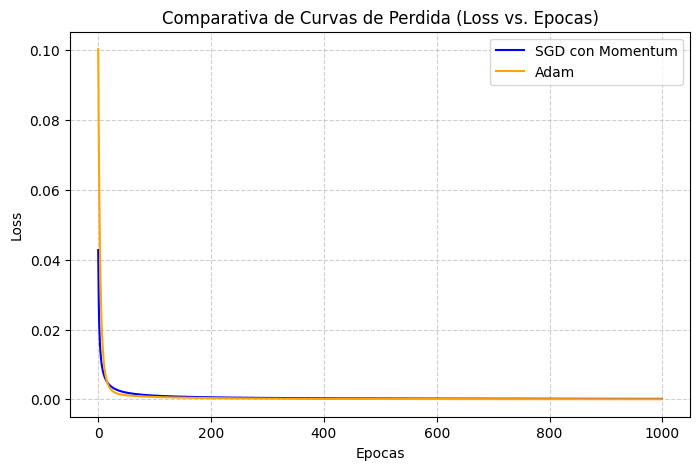

In [304]:
plt.figure(figsize=(8,5))
plt.plot(loss_momentum, label='SGD con Momentum', color='blue')
plt.plot(loss_adam, label='Adam', color='orange')
plt.title('Comparativa de Curvas de Perdida (Loss vs. Epocas)')
plt.xlabel('Epocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

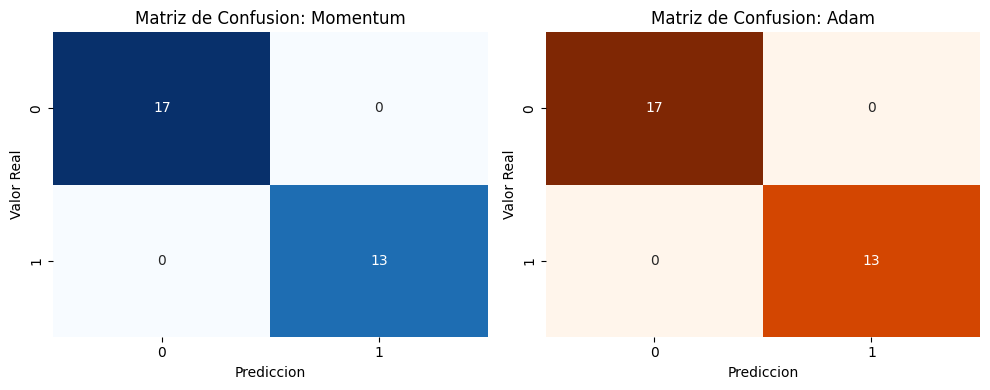

In [305]:
cm_momentum = confusion_matrix(y_test, y_pred_momentum)
cm_adam = confusion_matrix(y_test, y_pred_adam)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm_momentum, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusion: Momentum')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Valor Real')

sns.heatmap(cm_adam, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusion: Adam')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()